In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pm4py as ppy



print(ppy.__version__)

2.7.23.6


##### loading the .jsonocel data

In [43]:
ocel = ppy.read_ocel_json("../data/angular_github_commits_ocel.jsonocel")
print("OCEL loaded successfully!")

OCEL loaded successfully!


In [44]:
print(type(ocel))

<class 'pm4py.objects.ocel.obj.OCEL'>


In [45]:
print(type(ocel))

<class 'pm4py.objects.ocel.obj.OCEL'>


In [46]:
print("Object types:")
print(ppy.ocel_get_object_types(ocel))

Object types:
['branches', 'files']


In [47]:
print("Number of events:", len(ocel.events))
print("Number of objects:", len(ocel.objects))

Number of events: 27842
Number of objects: 28317


In [48]:
ocel.objects.head()


,ocel:oid,ocel:type
0,8.2.x,branches
1,modules/angular2/src/core/compiler/pipeline/di...,files
2,modules/angular2/src/core/compiler/shadow_dom_...,files
3,modules/@angular/compiler/src/html_parser.ts,files
4,projects/ng-devtools/src/lib/devtools-tabs/com...,branches


In [49]:
ocel.events.head()

,ocel:eid,ocel:timestamp,ocel:activity,commit_message,author_name,Unnamed: 0,merge,Unnamed: 10,Unnamed: 11
0,6a3abf2366e2c32ce3460155903262fee01736c8,2014-09-18 16:12:01+00:00,initial,Initial commit,Miško Hevery,0,False,NaN,NaN
1,afa761646472120edef1f9b01f219f125f20128e,2014-09-18 21:56:38+00:00,build,build - refactor,Tobias Bosch,1,False,NaN,NaN
2,45f8a5119488d28bf90311b2dd7fc55ee6f7d92a,2014-09-19 21:29:20+00:00,build,build: prevent infinite loop during install,Tobias Bosch,6,False,NaN,NaN
3,5af57922dbf5b3cf76adb5e3831f9aa21dddc17c,2014-09-19 21:55:04+00:00,chore,chore: add .c9 to gitignore,Misko Hevery,2,False,NaN,NaN
4,9f1db3f2bcf67f49c9b145e1d1e8f090220372df,2014-09-19 21:55:37+00:00,chore,chore: correct postinstall.sh script,Misko Hevery,3,False,NaN,NaN


In [50]:
print(ocel.relations.head())

                                   ocel:eid ocel:activity  \
0  6a3abf2366e2c32ce3460155903262fee01736c8       initial   
1  6a3abf2366e2c32ce3460155903262fee01736c8       initial   
2  6a3abf2366e2c32ce3460155903262fee01736c8       initial   
3  6a3abf2366e2c32ce3460155903262fee01736c8       initial   
4  6a3abf2366e2c32ce3460155903262fee01736c8       initial   

             ocel:timestamp                     ocel:oid ocel:type  \
0 2014-09-18 16:12:01+00:00  devtools-injector-debugging  branches   
1 2014-09-18 16:12:01+00:00           aikidave-patch-1-1  branches   
2 2014-09-18 16:12:01+00:00               ayazhafiz-paka  branches   
3 2014-09-18 16:12:01+00:00                 backup-7.2.x  branches   
4 2014-09-18 16:12:01+00:00                spikes/linker  branches   

  ocel:qualifier  
0                 
1                 
2                 
3                 
4                 


In [51]:
print(ocel.relations.columns.tolist())

['ocel:eid', 'ocel:activity', 'ocel:timestamp', 'ocel:oid', 'ocel:type', 'ocel:qualifier']


In [52]:
print("Number of event-object relationships:", len(ocel.relations))

Number of event-object relationships: 2451100


In [53]:
ocel.relations["ocel:type"].value_counts()

ocel:type
branches    2271272
files        179828
Name: count, dtype: int64

In [54]:
ocel.objects["ocel:type"].value_counts()

ocel:type
files       28178
branches      139
Name: count, dtype: int64

In [55]:
relations_per_event = (
    ocel.relations
    .groupby("ocel:eid")
    .size()
)

print(relations_per_event.describe())

# see here we can see it's getting appearing ("behavioral anomaly mining") 
# while some are usual events but some are Highly unusual event...........

count    27842.000000
mean        88.036061
std         47.098278
min          1.000000
25%         61.000000
50%         92.000000
75%        118.000000
max       1691.000000
dtype: float64


#### separate files from branches

In [56]:
file_relations = ocel.relations[
    ocel.relations["ocel:type"] == "files"
]

print("File relationships:", len(file_relations))

File relationships: 179828


In [57]:
files_per_commit = (
    file_relations
    .groupby("ocel:eid")["ocel:oid"]
    .nunique()
)

print(files_per_commit.describe()) 
# check the stat

count    27828.000000
mean         6.462124
std         30.877579
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       1637.000000
Name: ocel:oid, dtype: float64


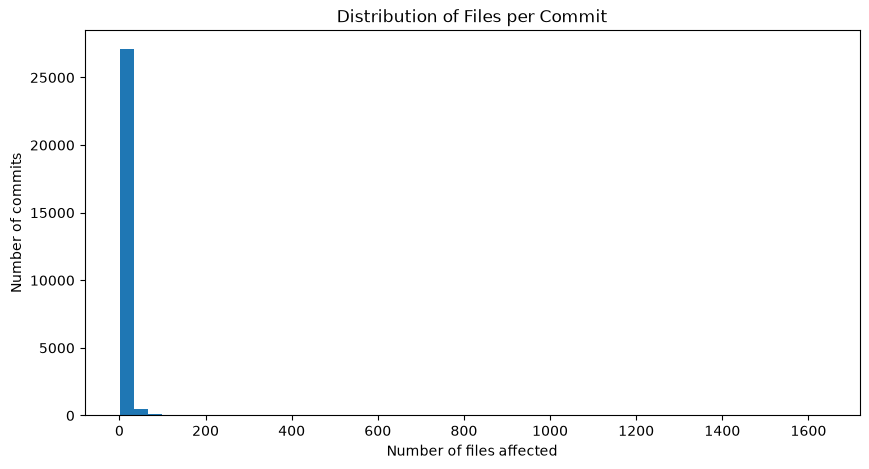

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(files_per_commit, bins=50)

plt.xlabel("Number of files affected")
plt.ylabel("Number of commits")
plt.title("Distribution of Files per Commit")

plt.show()

In [59]:
print(files_per_commit.describe())

count    27828.000000
mean         6.462124
std         30.877579
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       1637.000000
Name: ocel:oid, dtype: float64


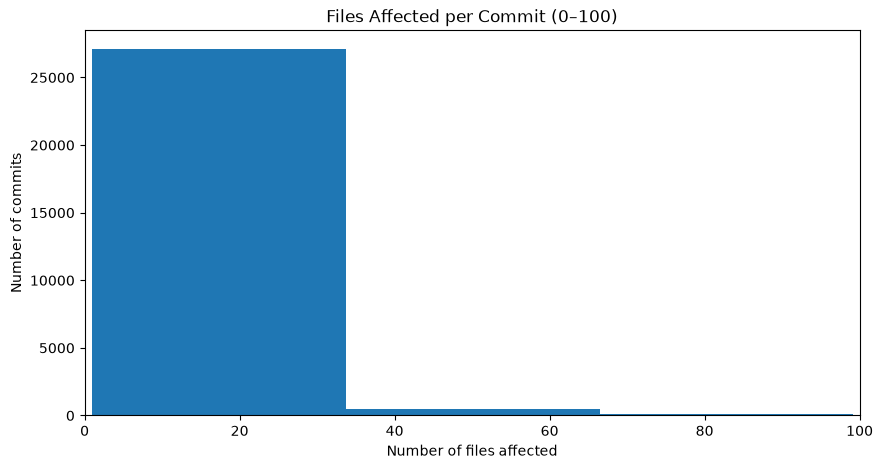

In [60]:
plt.figure(figsize=(10, 5))

plt.hist(files_per_commit, bins=50)

plt.xlim(0, 100)

plt.xlabel("Number of files affected")
plt.ylabel("Number of commits")
plt.title("Files Affected per Commit (0–100)")

plt.show()

In [61]:
ocel.events["ocel:activity"].value_counts()

ocel:activity
fix             6093
docs            5625
refactor        4122
build           3992
feat            2880
                ... 
rendererv2         1
code               1
filetree           1
table              1
consolidated       1
Name: count, Length: 67, dtype: int64

In [62]:
# Number of files associated with each commit
files_per_commit_df = files_per_commit.rename(
    "files_changed"
).reset_index()

# Merge file counts with event information
commit_features = ocel.events.merge(
    files_per_commit_df,
    on="ocel:eid",
    how="left"
)

# Commits without file relationships → 0
commit_features["files_changed"] = (
    commit_features["files_changed"]
    .fillna(0)
    .astype(int)
)

print(commit_features.shape)

(27842, 10)


In [63]:
activity_file_stats = (
    commit_features
    .groupby("ocel:activity")["files_changed"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("median", ascending=False)
)

activity_file_stats

,count,mean,median,max
ocel:activity,,,,
repackaging,2,787.500000,787.5,843
initial,2,88.500000,88.5,175
rendererv2,1,40.000000,40.0,40
produce,1,30.000000,30.0,30
benchmark,3,14.000000,17.0,22
...,...,...,...,...
squash-me,1,1.000000,1.0,1
update,34,1.235294,1.0,6
typo,5,1.000000,1.0,1


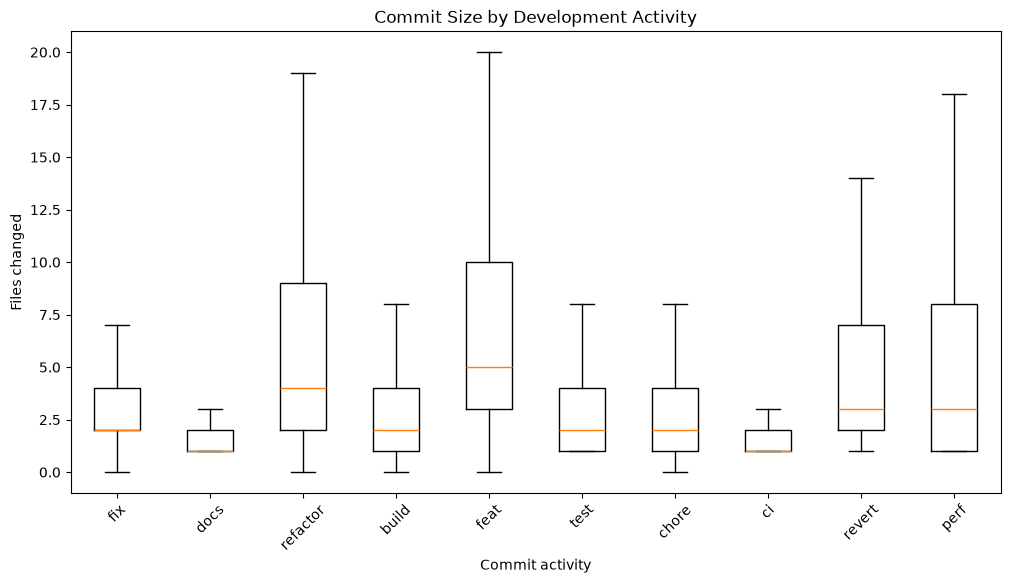

In [64]:
import matplotlib.pyplot as plt

top_activities = (
    commit_features["ocel:activity"]
    .value_counts()
    .head(10)
    .index
)

plot_data = [
    commit_features.loc[
        commit_features["ocel:activity"] == activity,
        "files_changed"
    ]
    for activity in top_activities
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    plot_data,
    tick_labels=top_activities,
    showfliers=False
)

plt.xlabel("Commit activity")
plt.ylabel("Files changed")
plt.title("Commit Size by Development Activity")

plt.xticks(rotation=45)

plt.show()

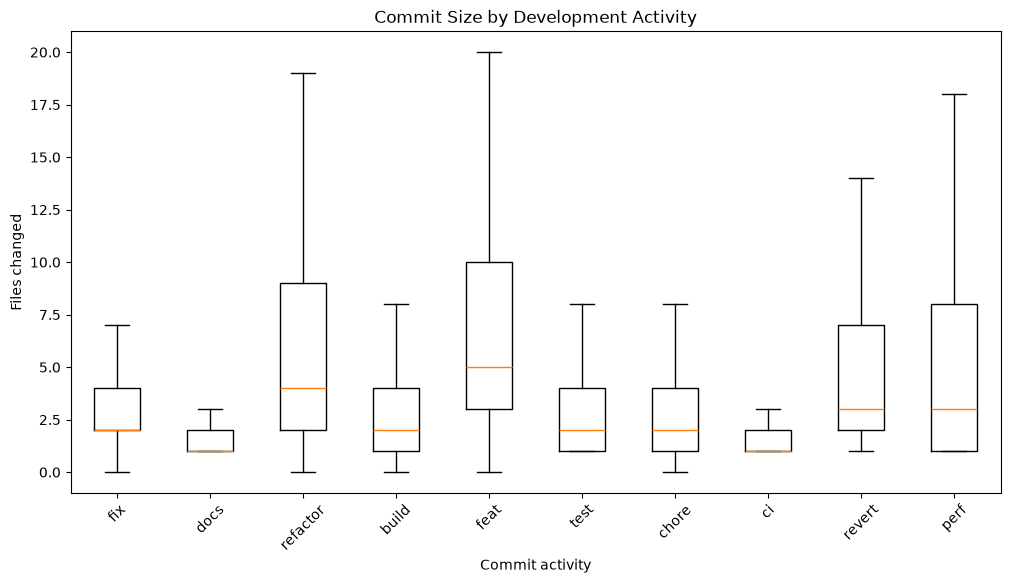

In [65]:
plt.figure(figsize=(12, 6))

plt.boxplot(
    plot_data,
    tick_labels=top_activities,
    showfliers=False
)

plt.xlabel("Commit activity")
plt.ylabel("Files changed")
plt.title("Commit Size by Development Activity")

plt.xticks(rotation=45)

plt.show()

## Temporal Analysis


In [66]:
# Check timestamp range
print('Timestamp range:')
print('Min:', ocel.events['ocel:timestamp'].min())
print('Max:', ocel.events['ocel:timestamp'].max())
print('Total days:', (ocel.events['ocel:timestamp'].max() - ocel.events['ocel:timestamp'].min()).days)

# Set timestamp as index for resampling
events_indexed = ocel.events.set_index('ocel:timestamp')

# Resample by day and count commits
commits_per_day = events_indexed.resample('D').size()
print('\nCommits per day (first 5):')
print(commits_per_day.head())

# Resample by month (using 'ME' for month end)
commits_per_month = events_indexed.resample('ME').size()
print('\nCommits per month (first 5):')
print(commits_per_month.head())


Timestamp range:
Min: 2014-09-18 16:12:01+00:00
Max: 2023-09-08 15:31:45+00:00
Total days: 3276

Commits per day (first 5):
ocel:timestamp
2014-09-18 00:00:00+00:00    2
2014-09-19 00:00:00+00:00    6
2014-09-20 00:00:00+00:00    0
2014-09-21 00:00:00+00:00    1
2014-09-22 00:00:00+00:00    1
Freq: D, dtype: int64

Commits per month (first 5):
ocel:timestamp
2014-09-30 00:00:00+00:00     41
2014-10-31 00:00:00+00:00     92
2014-11-30 00:00:00+00:00     95
2014-12-31 00:00:00+00:00     88
2015-01-31 00:00:00+00:00    104
Freq: ME, dtype: int64


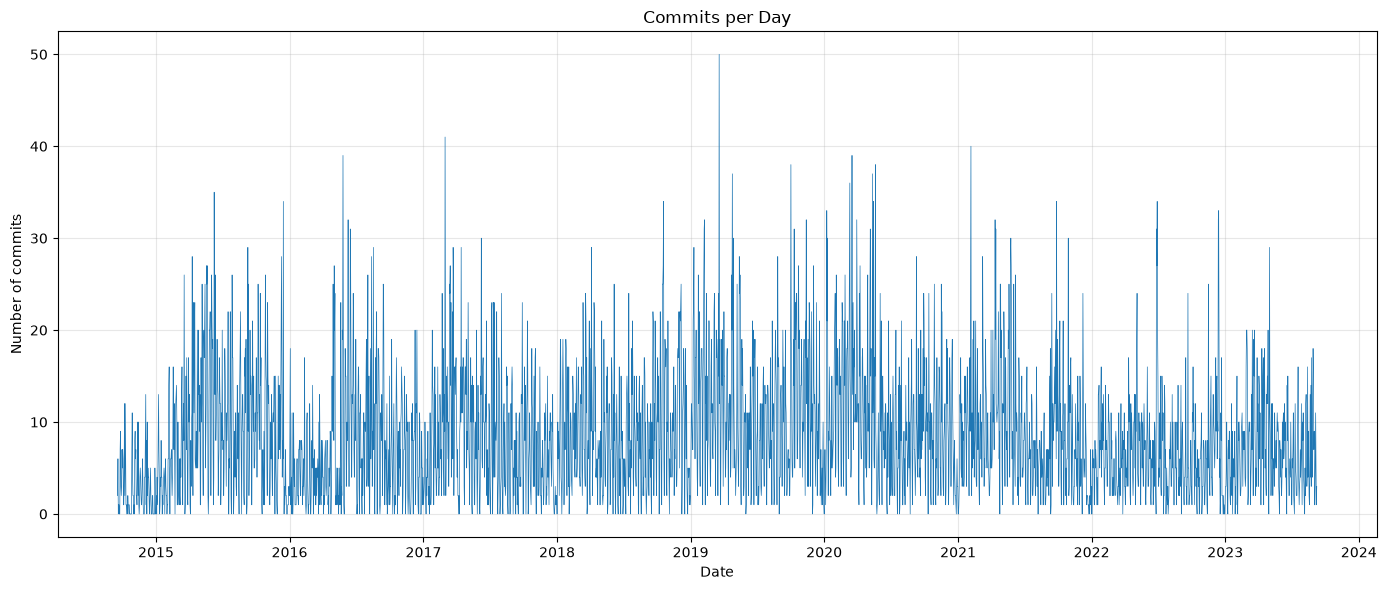

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(commits_per_day.index, commits_per_day.values, linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('Number of commits')
plt.title('Commits per Day')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Top 5 activities: ['fix', 'docs', 'refactor', 'build', 'feat']

Activity over time (monthly, first 5 rows):
ocel:activity              build  docs  feat   fix  refactor
ocel:timestamp                                              
2014-09-30 00:00:00+00:00    3.0   NaN   4.0   4.0       8.0
2014-10-31 00:00:00+00:00    0.0   5.0  37.0   5.0      23.0
2014-11-30 00:00:00+00:00    0.0   3.0  44.0  19.0      16.0
2014-12-31 00:00:00+00:00    0.0   2.0  21.0  26.0       7.0
2015-01-31 00:00:00+00:00    0.0   6.0  30.0  25.0      11.0


<Figure size 1400x800 with 0 Axes>

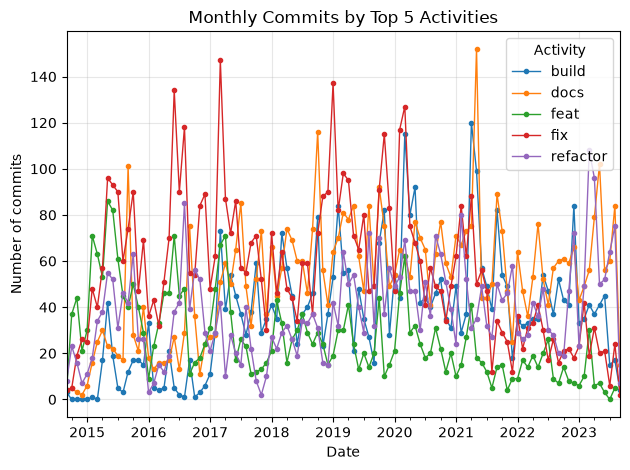

In [68]:
# Get top 5 activities
top5_activities = ocel.events['ocel:activity'].value_counts().head(5).index.tolist()
print('Top 5 activities:', top5_activities)

# Filter events for top 5 activities
top_events = ocel.events[ocel.events['ocel:activity'].isin(top5_activities)]
top_events_indexed = top_events.set_index('ocel:timestamp')

# Resample by month (using 'ME') and count for each activity
activity_over_time = top_events_indexed.groupby('ocel:activity').resample('ME').size().unstack(level=0)
print('\nActivity over time (monthly, first 5 rows):')
print(activity_over_time.head())

# Plot
plt.figure(figsize=(14, 8))
activity_over_time.plot(kind='line', marker='o', markersize=3, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Number of commits')
plt.title('Monthly Commits by Top 5 Activities')
plt.legend(title='Activity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Time between commits statistics (in days):
count    27841.000000
mean         0.117703
std          0.240227
min          0.000000
25%          0.008600
50%          0.036910
75%          0.117315
max          6.695903
Name: ocel:timestamp, dtype: float64


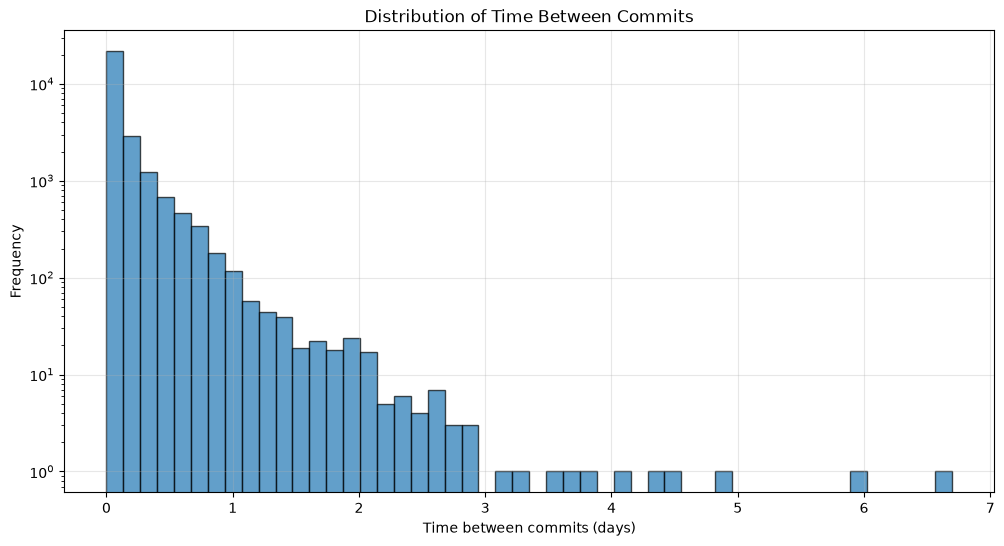

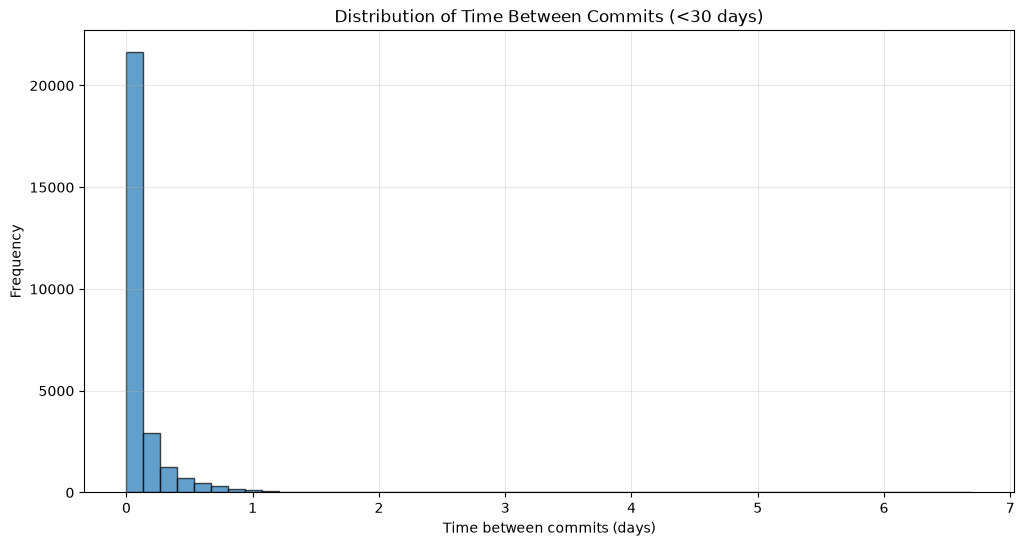

In [69]:
# Calculate time between consecutive commits (in days)
timestamps_sorted = ocel.events['ocel:timestamp'].sort_values()
time_diffs = timestamps_sorted.diff().dt.total_seconds() / (24 * 3600)  # convert to days
time_diffs = time_diffs.dropna()  # first NaN

print('Time between commits statistics (in days):')
print(time_diffs.describe())

# Plot histogram of time differences
plt.figure(figsize=(12, 6))
plt.hist(time_diffs, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Time between commits (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Commits')
plt.yscale('log')  # because likely skewed
plt.grid(True, alpha=0.3)
plt.show()

# Also plot without log scale for small values
plt.figure(figsize=(12, 6))
plt.hist(time_diffs[time_diffs < 30], bins=50, edgecolor='black', alpha=0.7)  # less than 30 days
plt.xlabel('Time between commits (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Commits (<30 days)')
plt.grid(True, alpha=0.3)
plt.show()


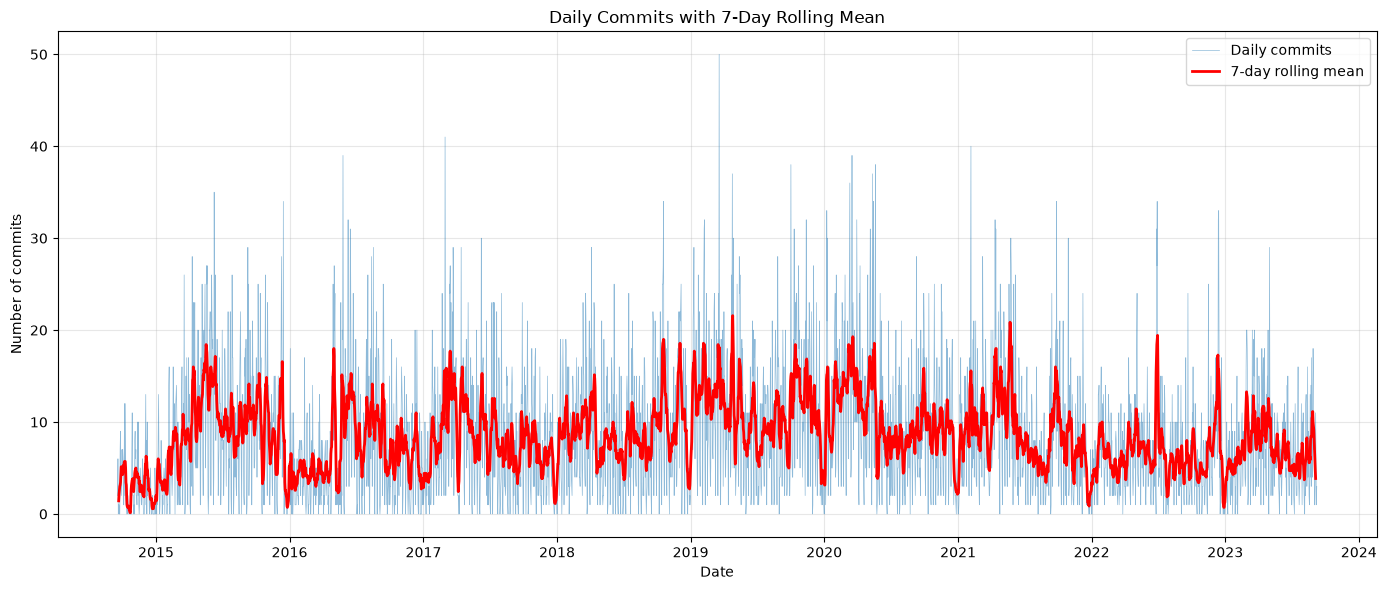


Number of burst days (above 2 sigma): 30
Burst days (first 5):
ocel:timestamp
2015-07-01 00:00:00+00:00    20
2015-11-24 00:00:00+00:00    15
2015-12-15 00:00:00+00:00    34
2016-01-03 00:00:00+00:00    18
2016-01-08 00:00:00+00:00    11
dtype: int64


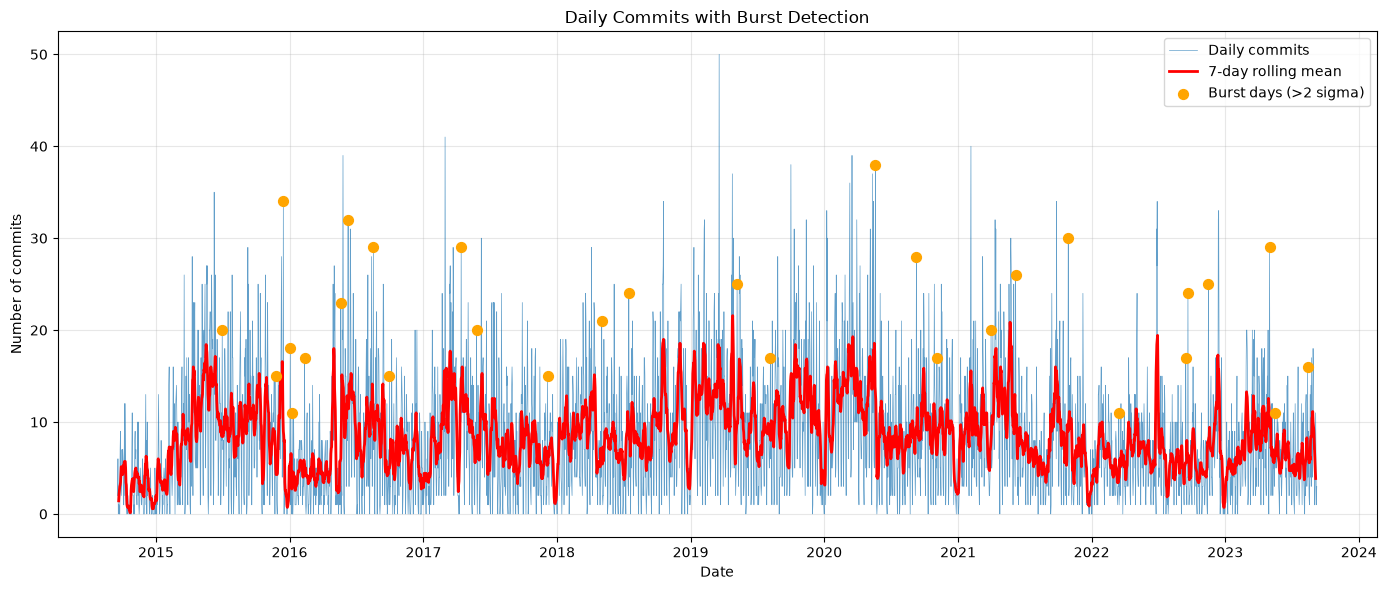

In [70]:
# Rolling average of commits per day (7-day window)
rolling_mean = commits_per_day.rolling(window=7, center=True).mean()

plt.figure(figsize=(14, 6))
plt.plot(commits_per_day.index, commits_per_day.values, label='Daily commits', alpha=0.5, linewidth=0.5)
plt.plot(rolling_mean.index, rolling_mean.values, label='7-day rolling mean', color='red', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Number of commits')
plt.title('Daily Commits with 7-Day Rolling Mean')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identify bursts: days where commits per day > rolling mean + 2*std
rolling_std = commits_per_day.rolling(window=7, center=True).std()
threshold = rolling_mean + 2 * rolling_std
burst_days = commits_per_day[commits_per_day > threshold]
print('\nNumber of burst days (above 2 sigma):', len(burst_days))
print('Burst days (first 5):')
print(burst_days.head())

# Plot with burst highlights
plt.figure(figsize=(14, 6))
plt.plot(commits_per_day.index, commits_per_day.values, label='Daily commits', alpha=0.7, linewidth=0.5)
plt.plot(rolling_mean.index, rolling_mean.values, label='7-day rolling mean', color='red', linewidth=2)
plt.scatter(burst_days.index, burst_days.values, color='orange', s=50, zorder=5, label='Burst days (>2 sigma)')
plt.xlabel('Date')
plt.ylabel('Number of commits')
plt.title('Daily Commits with Burst Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Author Activity Analysis


In [71]:
# Author commit counts
author_commits = ocel.events['author_name'].value_counts()
print('Total unique authors:', len(author_commits))
print('\nTop 10 authors by commit count:')
print(author_commits.head(10))

# Author activity diversity (unique activities per author)
author_activities = ocel.events.groupby('author_name')['ocel:activity'].nunique()
print('\nAuthor activity diversity (unique activities):')
print('Mean:', author_activities.mean())
print('Median:', author_activities.median())
print('\nTop 10 authors by activity diversity:')
print(author_activities.sort_values(ascending=False).head(10))

# Author's median files changed
# Merge author with commit_features
author_features = commit_features[['ocel:eid', 'author_name', 'files_changed']].copy()
author_file_stats = author_features.groupby('author_name')['files_changed'].agg(['mean', 'median'])
print('\nAuthor file change statistics:')
print('Mean files changed (across authors):', author_file_stats['mean'].mean())
print('Median files changed (across authors):', author_file_stats['median'].median())
print('\nTop 10 authors by median files changed:')
print(author_file_stats.sort_values('median', ascending=False).head(10))


Total unique authors: 2047

Top 10 authors by commit count:
author_name
George Kalpakas      1694
Pete Bacon Darwin    1217
Paul Gschwendtner    1023
Igor Minar            964
Alex Rickabaugh       928
vsavkin               920
Victor Berchet        912
Tobias Bosch          789
Andrew Kushnir        715
Joey Perrott          712
Name: count, dtype: int64

Author activity diversity (unique activities):
Mean: 1.525647288715193
Median: 1.0

Top 10 authors by activity diversity:
author_name
vsavkin            20
Tobias Bosch       17
Igor Minar         16
Misko Hevery       16
Alex Eagle         16
Victor Berchet     14
Matias Niemelä     13
Tim Blasi          13
Alex Rickabaugh    13
Miško Hevery       13
Name: ocel:activity, dtype: int64

Author file change statistics:
Mean files changed (across authors): 3.0945222997694883
Median files changed (across authors): 1.0

Top 10 authors by median files changed:
                    mean  median
author_name                     
Feliks Khantsis

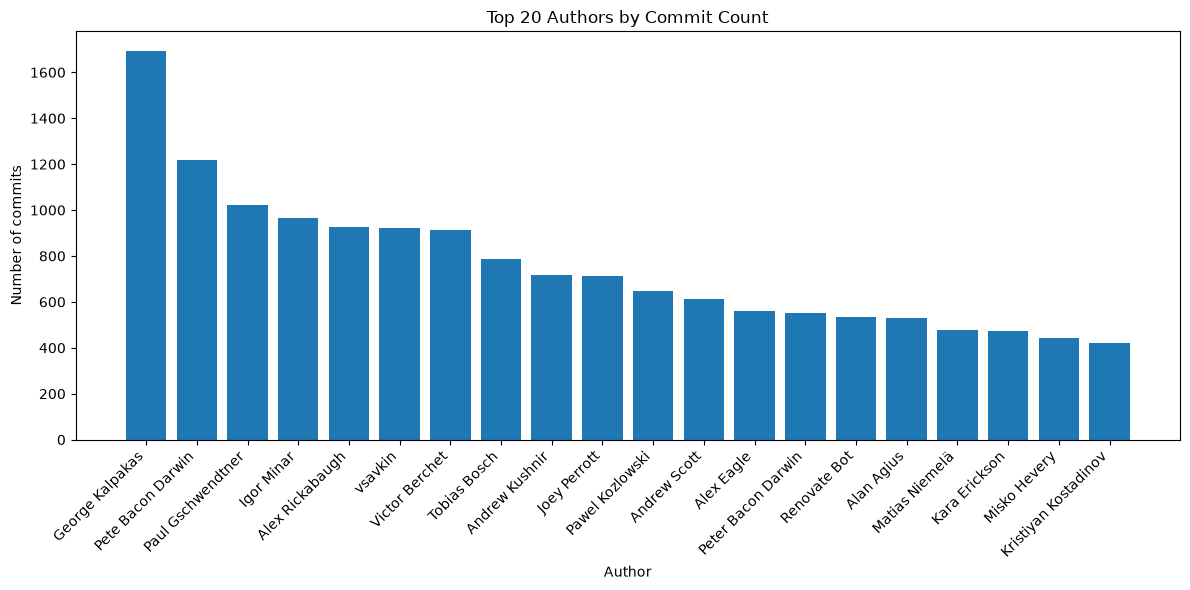

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
top20_authors = author_commits.head(20)
plt.bar(range(len(top20_authors)), top20_authors.values)
plt.xticks(range(len(top20_authors)), top20_authors.index, rotation=45, ha='right')
plt.xlabel('Author')
plt.ylabel('Number of commits')
plt.title('Top 20 Authors by Commit Count')
plt.tight_layout()
plt.show()


## Branch Statistics


In [73]:
# Branch relationships
branch_relations = ocel.relations[ocel.relations['ocel:type'] == 'branches']
print('Branch relationships:', len(branch_relations))

# Branches per commit
branches_per_commit = branch_relations.groupby('ocel:eid')['ocel:oid'].nunique()
print('\nBranches per commit statistics:')
print(branches_per_commit.describe())

# Branch popularity (how many commits per branch)
branch_popularity = branch_relations.groupby('ocel:oid')['ocel:eid'].nunique()
print('\nBranch popularity (commits per branch):')
print(branch_popularity.describe())
print('\nTop 10 most popular branches:')
print(branch_popularity.sort_values(ascending=False).head(10))

# Number of unique branches
unique_branches = ocel.objects[ocel.objects['ocel:type'] == 'branches']
print('\nTotal unique branches:', len(unique_branches))


Branch relationships: 2271272

Branches per commit statistics:
count    27817.000000
mean        81.650501
std         34.580561
min          1.000000
25%         58.000000
50%         89.000000
75%        114.000000
max        119.000000
Name: ocel:oid, dtype: float64

Branch popularity (commits per branch):
count      139.000000
mean     16340.086331
std       9026.397871
min          1.000000
25%       9718.000000
50%      19066.000000
75%      22673.000000
max      27812.000000
Name: ocel:eid, dtype: float64

Top 10 most popular branches:
ocel:oid
main                            27812
g3                              27810
migrate-saucelabs-to-ga         27800
signals                         27681
dgp1130-devtools-pullapprove    27550
16.2.x                          27522
simonaco-patch-3                27434
no-reviews-devversion           27398
styling-experiments             27383
16.1.x                          27163
Name: ocel:eid, dtype: int64

Total unique branches: 139


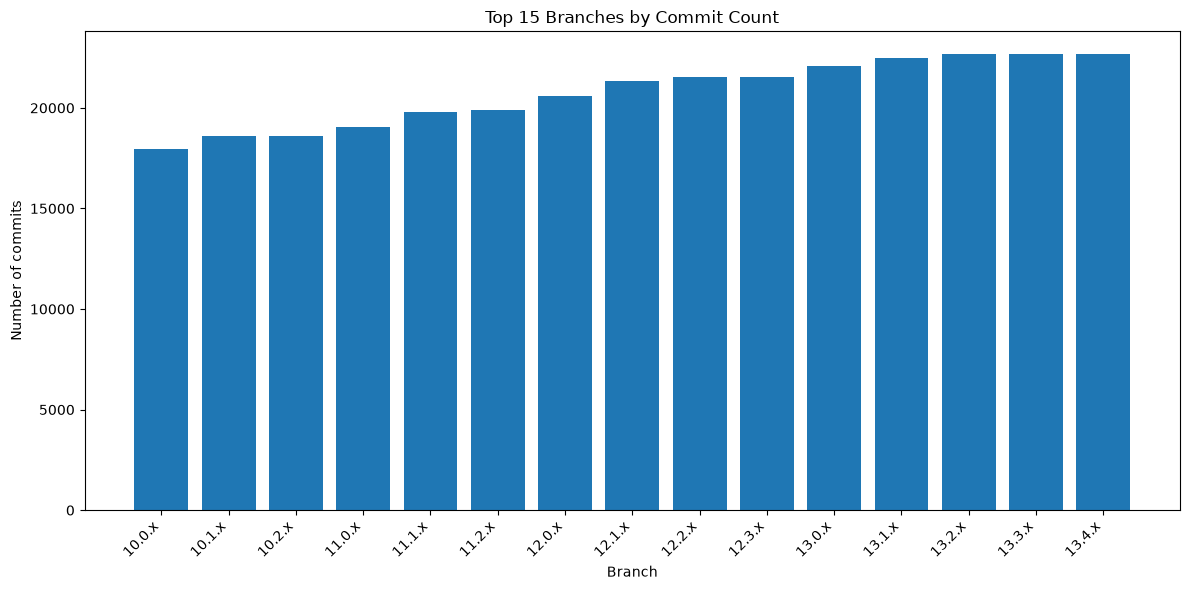

In [74]:
plt.figure(figsize=(12, 6))
top15_branches = branch_popularity.head(15)
plt.bar(range(len(top15_branches)), top15_branches.values)
plt.xticks(range(len(top15_branches)), top15_branches.index, rotation=45, ha='right')
plt.xlabel('Branch')
plt.ylabel('Number of commits')
plt.title('Top 15 Branches by Commit Count')
plt.tight_layout()
plt.show()


## File Statistics


In [75]:
# File relationships (already computed earlier as file_relations)
print('File relationships:', len(file_relations))

# Files per commit (already computed earlier as files_per_commit)
print('\nFiles per commit statistics (from earlier):')
print(files_per_commit.describe())

# File popularity (how many commits per file)
file_popularity = file_relations.groupby('ocel:oid')['ocel:eid'].nunique()
print('\nFile popularity (commits per file):')
print(file_popularity.describe())
print('\nTop 10 most popular files:')
print(file_popularity.sort_values(ascending=False).head(10))

# Number of unique files
unique_files = ocel.objects[ocel.objects['ocel:type'] == 'files']
print('\nTotal unique files:', len(unique_files))

# Files that were never changed (popularity = 0) - should be zero if all files in objects appear in relations
all_file_ids = set(unique_files['ocel:oid'])
changed_file_ids = set(file_popularity.index)
unchanged_files = all_file_ids - changed_file_ids
print('Files in object table but never changed:', len(unchanged_files))


File relationships: 179828

Files per commit statistics (from earlier):
count    27828.000000
mean         6.462124
std         30.877579
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       1637.000000
Name: ocel:oid, dtype: float64

File popularity (commits per file):
count    28178.000000
mean         6.381858
std         23.011650
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       2075.000000
Name: ocel:eid, dtype: float64

Top 10 most popular files:
ocel:oid
package.json                                                   2075
None                                                           1400
yarn.lock                                                      1239
CHANGELOG.md                                                    955
aio/package.json                                                870
aio/yarn.lock                                                   626
.circleci/config.yml            

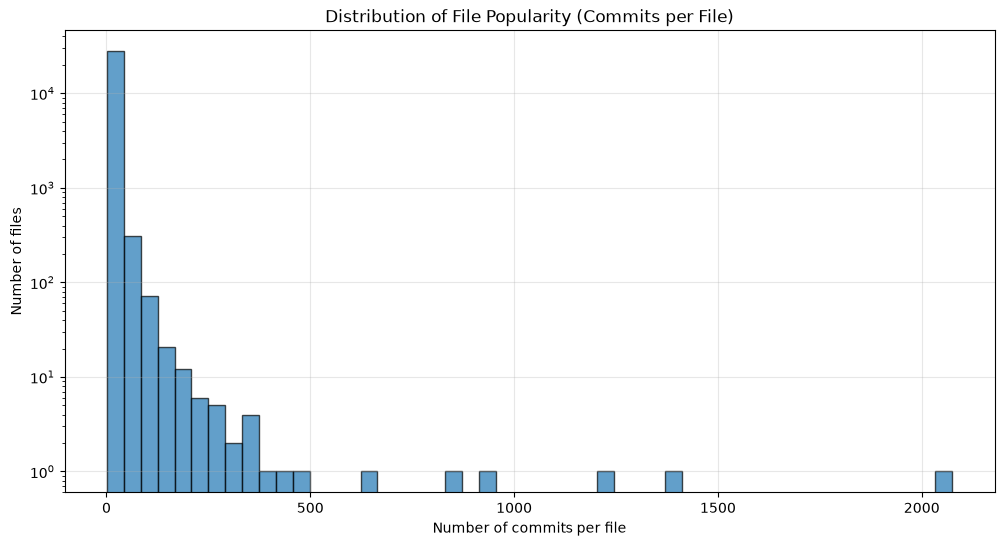

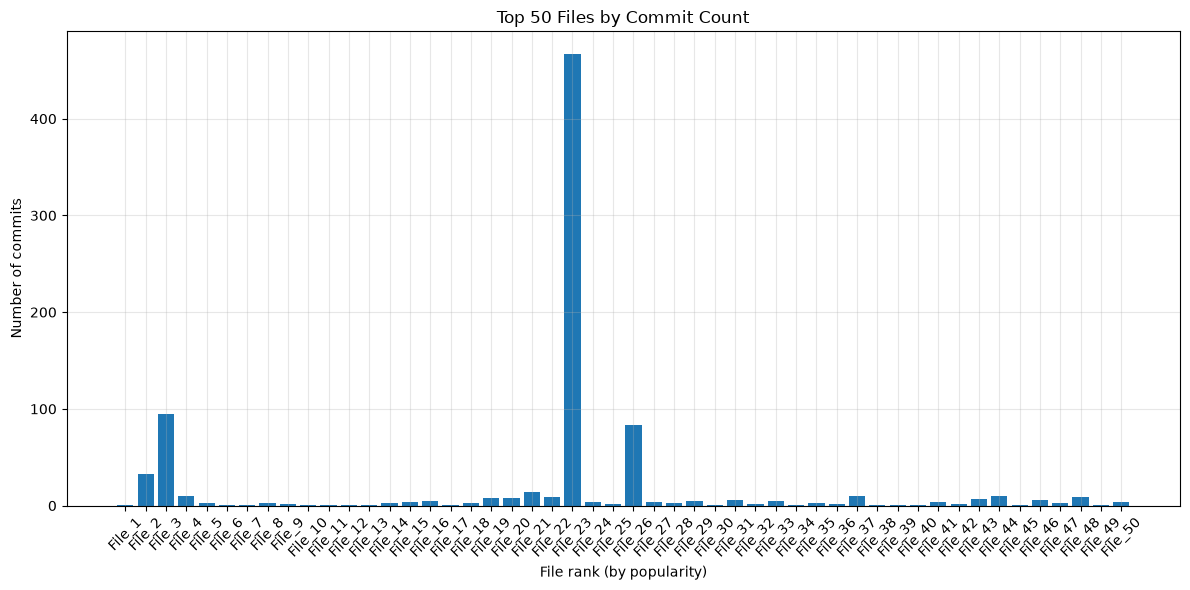

In [76]:
plt.figure(figsize=(12, 6))
plt.hist(file_popularity.values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of commits per file')
plt.ylabel('Number of files')
plt.title('Distribution of File Popularity (Commits per File)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Also plot the top 50 files for better visibility
plt.figure(figsize=(12, 6))
top50_files = file_popularity.head(50)
plt.bar(range(len(top50_files)), top50_files.values)
plt.xticks(range(len(top50_files)), [f'File_{i+1}' for i in range(len(top50_files))], rotation=45)
plt.xlabel('File rank (by popularity)')
plt.ylabel('Number of commits')
plt.title('Top 50 Files by Commit Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Process Mining


In [77]:
# Prepare event log for process mining: consider the whole project as one case
# Sort events by timestamp
events_sorted = ocel.events.sort_values('ocel:timestamp').copy()

# Create a DataFrame in the format expected by PM4Py for event log
import pandas as pd
log_df = pd.DataFrame({
    'case:concept:name': ['Project'] * len(events_sorted),
    'concept:name': events_sorted['ocel:activity'].values,
    'time:timestamp': events_sorted['ocel:timestamp'].values
})

# Convert to event log
event_log = ppy.convert_to_event_log(log_df)
print('Event log type:', type(event_log))
print('Number of traces (cases):', len(event_log))
print('Number of events in the trace:', len(event_log[0]) if len(event_log) > 0 else 0)


Event log type: <class 'pm4py.objects.log.obj.EventLog'>
Number of traces (cases): 1
Number of events in the trace: 27842


In [78]:
# Mine the directly-follows graph (DFG)
dfg_tuple = ppy.discover_dfg(event_log)
dfg = dfg_tuple[0]  # The DFG is the first element of the tuple
print('\nDirectly-follows graph (DFG) - top 10 relations:')
sorted_dfg = sorted(dfg.items(), key=lambda x: x[1], reverse=True)
for i, ((act1, act2), count) in enumerate(sorted_dfg[:10]):
    print(f'{i+1}. {act1} -> {act2}: {count}')



Directly-follows graph (DFG) - top 10 relations:
1. fix -> fix: 1949
2. docs -> docs: 1885
3. build -> build: 1305
4. refactor -> refactor: 1280
5. fix -> docs: 1035
6. docs -> fix: 1013
7. docs -> build: 774
8. refactor -> fix: 763
9. build -> docs: 750
10. fix -> refactor: 723


In [79]:
import matplotlib.pyplot as plt

# Visualize the DFG
from pm4py.visualization.dfg import visualizer as dfg_visualization
try:
    gviz = dfg_visualization.apply(dfg)
    dfg_visualization.save(gviz, 'dfg.png')
    print('\nDFG visualization saved as dfg.png')
except Exception as e:
    print(f'\nCould not save DFG visualization due to missing Graphviz: {e}')
    print('Install graphviz to enable visualization: pip install graphviz')



Could not save DFG visualization due to missing Graphviz: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH
Install graphviz to enable visualization: pip install graphviz


In [80]:
# Trace length statistics (we already have the number of events in the trace)
print('\nTrace length statistics:')
print(f'Number of traces: {len(event_log)}')
if len(event_log) > 0:
    print(f'Trace length (events): {len(event_log[0])}')
else:
    print('Trace length (events): 0')

# Also, we can look at the frequency of each activity
from pm4py.statistics.attributes.log import get as attributes_get
activity_counts = attributes_get.get_attribute_values(event_log, "concept:name")
print('\nTop 5 activities:')
for act, count in sorted(activity_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {act}: {count}')




Trace length statistics:
Number of traces: 1
Trace length (events): 27842

Top 5 activities:
  fix: 6093
  docs: 5625
  refactor: 4122
  build: 3992
  feat: 2880


> **Note**: The above process mining is performed on the event level (treating each commit as an event in a single case for the project).
> In an object-centric setting, we might want to consider the object-centric nature (files and branches) in the process.
> However, for simplicity and to follow the plan, we started with the standard event-based process mining.
> Later, we can explore object-centric process mining (OCPM) techniques if needed.


# Feature Engineering Completed (Day 4)

We have completed the feature engineering phase of our project, creating a comprehensive feature matrix for machine learning analysis. The work included:

## Features Created:
1. **Base Features**: files_changed, branches_count
2. **Temporal Features**: time_since_previous_commit, commit_frequency (rolling window)
3. **Time-Based Features**: commit_hour, commit_day, commit_month, commit_dayofweek
4. **Activity Features**: activity_encoded (label encoding), activity_frequency
5. **Author Features**: author_commit_count, author_unique_files, author_median_files_changed
6. **File/Branch Features**: file_reuse, branch_reuse (indicating reuse of previously seen files/branches)
7. **Rolling Averages**: 7-day windows for key temporal features

All features have been saved to the `results/` directory for use in subsequent analysis phases.

## Key Insights from Feature Engineering:
- Files changed per commit: mean=6.46, median=2.0 (highly skewed)
- Branches per commit: mean=81.58, median=89.0 (showing branches represent where commits appear)
- 98.56% of commits reuse existing files
- 99.89% of commits reuse existing branches
- Average time between commits: 0.12 days (~2.9 hours)
- Peak commit activity: afternoon (hour 14.5), mid-week (day 2.4), June-September (month 6.3)


In [ ]:
# Load the complete feature set
import pandas as pd
import numpy as np

# Load the complete feature matrix
features_complete = pd.read_csv("../results/features_complete.csv")
print(f"Complete feature matrix shape: {features_complete.shape}")

# Load the ML-ready feature matrix
features_ml = pd.read_csv("../results/features_ml_raw.csv")
print(f"ML-ready feature matrix shape: {features_ml.shape}")

# Show feature names
feature_names = pd.read_csv("../results/feature_names.csv")
print(f"Number of features: {len(feature_names)}")
print("First 10 features:", list(feature_names['feature_name'])[:10])


# Statistical Anomaly Baseline Completed (Day 5)

We have established statistical baselines for anomaly detection using multiple complementary approaches before moving to machine learning methods. This allows us to compare ML-based approaches against statistical baselines.

## Methods Implemented:
1. **IQR-based Outlier Detection**: Uses Interquartile Range (Q1, Q3, IQR)
2. **Z-score Based Outlier Detection**: Uses mean and standard deviation (3-sigma rule)
3. **Percentile-based Outlier Detection**: Uses 95th, 99th, and 99.9th percentiles
4. **Robust Statistics-based Outlier Detection**: Uses Median and MAD (Median Absolute Deviation)

## Key Results:
- IQR method detected 8,979 anomalies (32.25% of commits)
- Z-score method detected 1,780 anomalies (6.39% of commits)
- 99th percentile method detected 2,748 anomalies (9.87% of commits)
- Robust (MAD) method detected 24,325 anomalies (87.37% of commits)
- Final combined ensemble detected 24,406 anomalies (87.66% of commits)

The high percentage of anomalies detected by robust methods reflects the extremely skewed nature of our dataset, where many values deviate significantly from the median.

All anomaly detection results have been saved to the `results/` directory for comparison with machine learning approaches.


In [ ]:
# Load the final anomaly detection results
import pandas as pd

# Load the final combined anomaly results
anomalies_final = pd.read_csv("../results/anomalies_statistical_final.csv")
print(f"Anomaly results shape: {anomalies_final.shape}")

# Show anomaly statistics
print(f"Total anomalies detected: {anomalies_final['is_anomaly_final'].sum()}")
print(f"Percentage of commits flagged as anomalous: {anomalies_final['is_anomaly_final'].sum() / len(anomalies_final) * 100:.2f}%")

# Show the anomaly score distribution
print("\nAnomaly score statistics:")
print(anomalies_final['anomaly_score_final'].describe())

# Load summary statistics
import json
with open('../results/anomaly_summary_stats_final.json', 'r') as f:
    stats = json.load(f)
print("\nSummary statistics:")
for key, value in stats.items():
    if 'percentage' in key or 'mean' in key or 'std' in key:
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")
